# Análise NBA — Milwaukee Bucks (MIL)
### Temporadas 2022 e 2023
**Disciplina:** Métodos Quantitativos para Computação — UNIFOR  
**Professor:** Prof. Me. Ricardo Carubbi  
**Equipe:** Milwaukee Bucks (MIL)  
**Temporadas analisadas:** 2022 e 2023

---


## 1. Importação e carregamento dos dados

In [ ]:
%pip install pandas matplotlib seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Carrega o dataset pré-processado
df = pd.read_csv('dataset/nba_stats_preprocessed.csv')

# Filtra o time MIL e separa as temporadas
df_mil  = df[df['sigla_time'] == 'MIL'].copy()
df_2022 = df_mil[df_mil['temporada'] == 2022].copy()
df_2023 = df_mil[df_mil['temporada'] == 2023].copy()

print(f'Jogadores MIL 2022: {len(df_2022)}')
print(f'Jogadores MIL 2023: {len(df_2023)}')
df_2022.head()

---
## 2. Análise da temporada 2022

Análise descritiva da temporada 2022 do MIL com média, mediana, moda e quartis.


### 2.1 Moda de pontos por posição

In [ ]:
# Moda de pontos por posição
moda_posicao = (
    df_2022.groupby('sigla_posicao')['pontos']
    .apply(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None)
    .reset_index()
)
moda_posicao.columns = ['sigla_posicao', 'moda_pontos']
display(moda_posicao)

### 2.2 Estatísticas descritivas — média, mediana, moda, Q1 e Q3

In [ ]:
cols = ['pontos', 'rebotes', 'assistencias', 'salario_usd']

resumo_2022 = pd.DataFrame({
    'Média':    df_2022[cols].mean(),
    'Mediana':  df_2022[cols].median(),
    'Moda':     df_2022[cols].mode().iloc[0],
    'Q1 (25%)': df_2022[cols].quantile(0.25),
    'Q3 (75%)': df_2022[cols].quantile(0.75),
})
display(resumo_2022.round(2))

### 2.3 Média vs Mediana — 2022

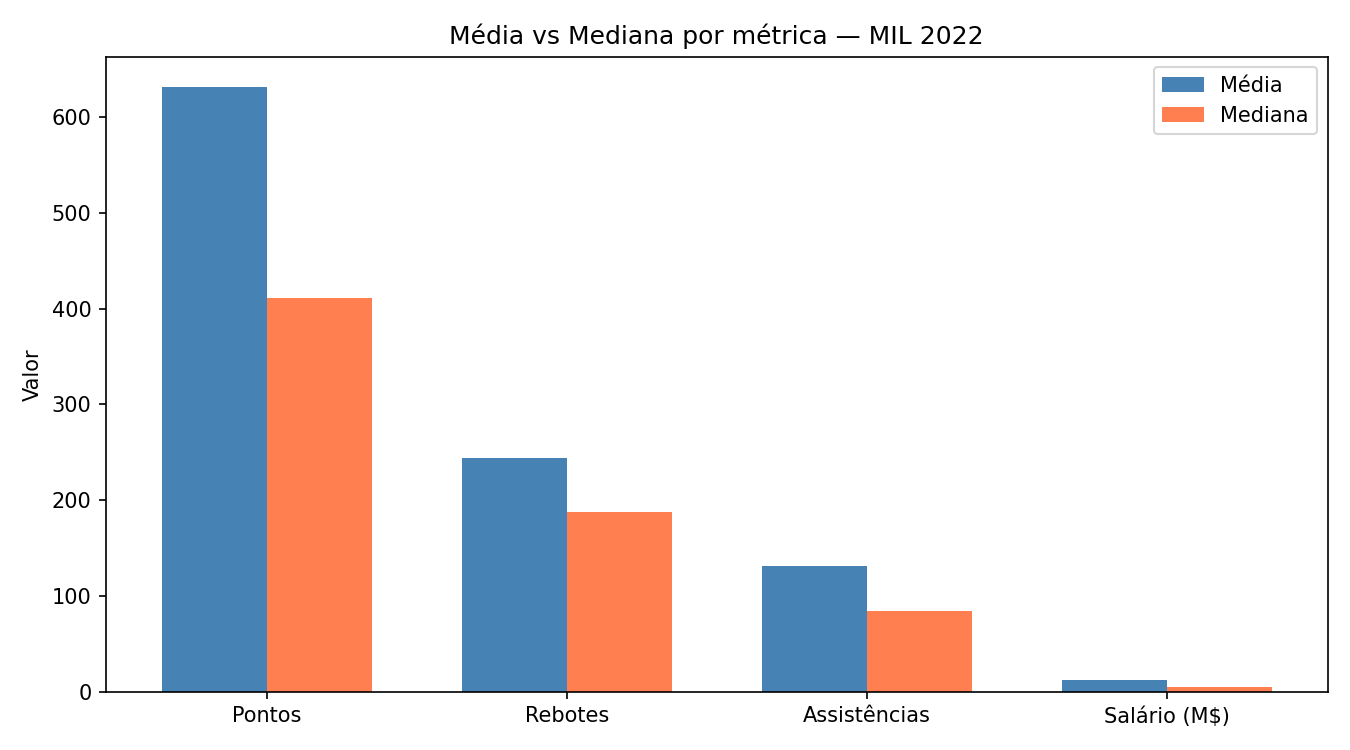

In [ ]:
# Gráfico: Média vs Mediana — MIL 2022

**Interpretação:** A média (631) é maior que a mediana (410) nos pontos, indicando distribuição assimétrica à direita — poucos jogadores com pontuação muito alta puxam a média para cima. A mediana representa melhor o jogador típico do elenco.


### 2.4 Boxplot de pontos — distribuição geral

In [ ]:
# Boxplot de pontos com média e moda
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    df_2022['pontos'].dropna(), vert=True, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='orange', markersize=6)
)
media = df_2022['pontos'].mean()
moda  = df_2022['pontos'].mode().iloc[0]
ax.axhline(media, color='green',  linestyle='--', linewidth=1.5, label=f'Média: {media:.0f}')
ax.axhline(moda,  color='purple', linestyle=':',  linewidth=1.5, label=f'Moda: {moda:.0f}')
ax.set_title('Distribuição de pontos — MIL 2022\n(vermelho=mediana, verde=média, roxo=moda)')
ax.set_ylabel('Pontos na temporada')
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.show()

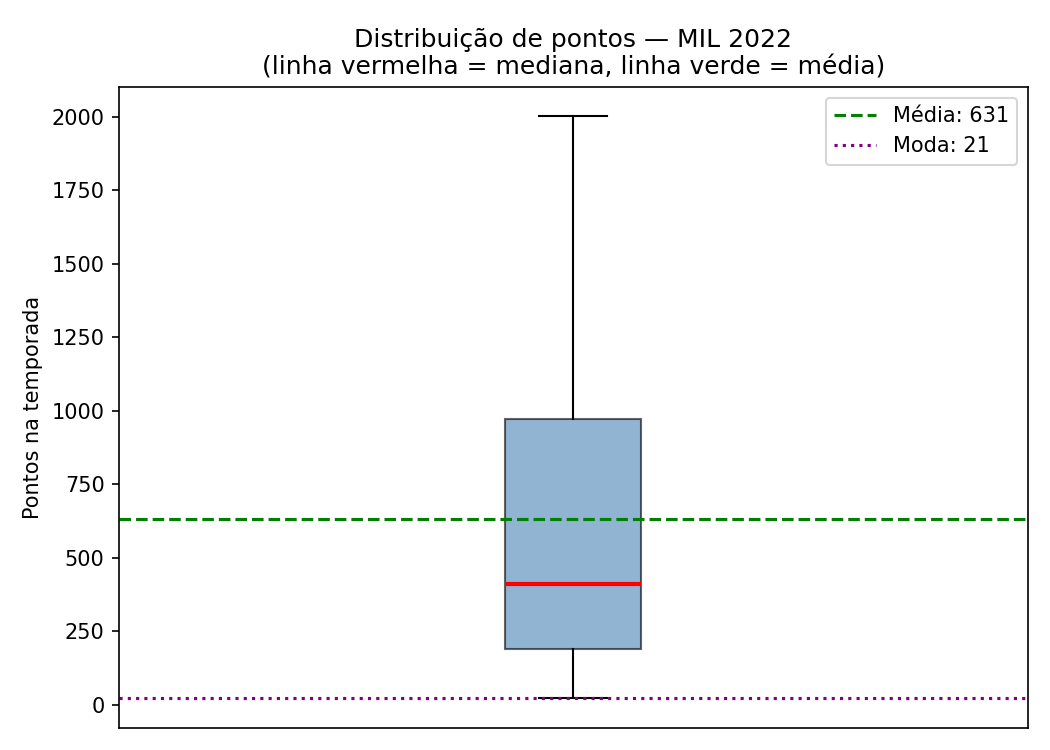

In [ ]:
# Boxplot pontos MIL 2022

**Interpretação:** A média (644) é maior que a mediana (516), o que indica que alguns jogadores com pontuações muito altas puxam a média para cima. Metade dos jogadores do MIL marcou menos de 516 pontos na temporada.


### 2.5 Boxplot de pontos por posição — 2022

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_2022, x='sigla_posicao', y='pontos', palette='Set2')
plt.title('Distribuição de pontos por posição — MIL 2022')
plt.xlabel('Posição')
plt.ylabel('Pontos na temporada')
plt.tight_layout()
plt.show()

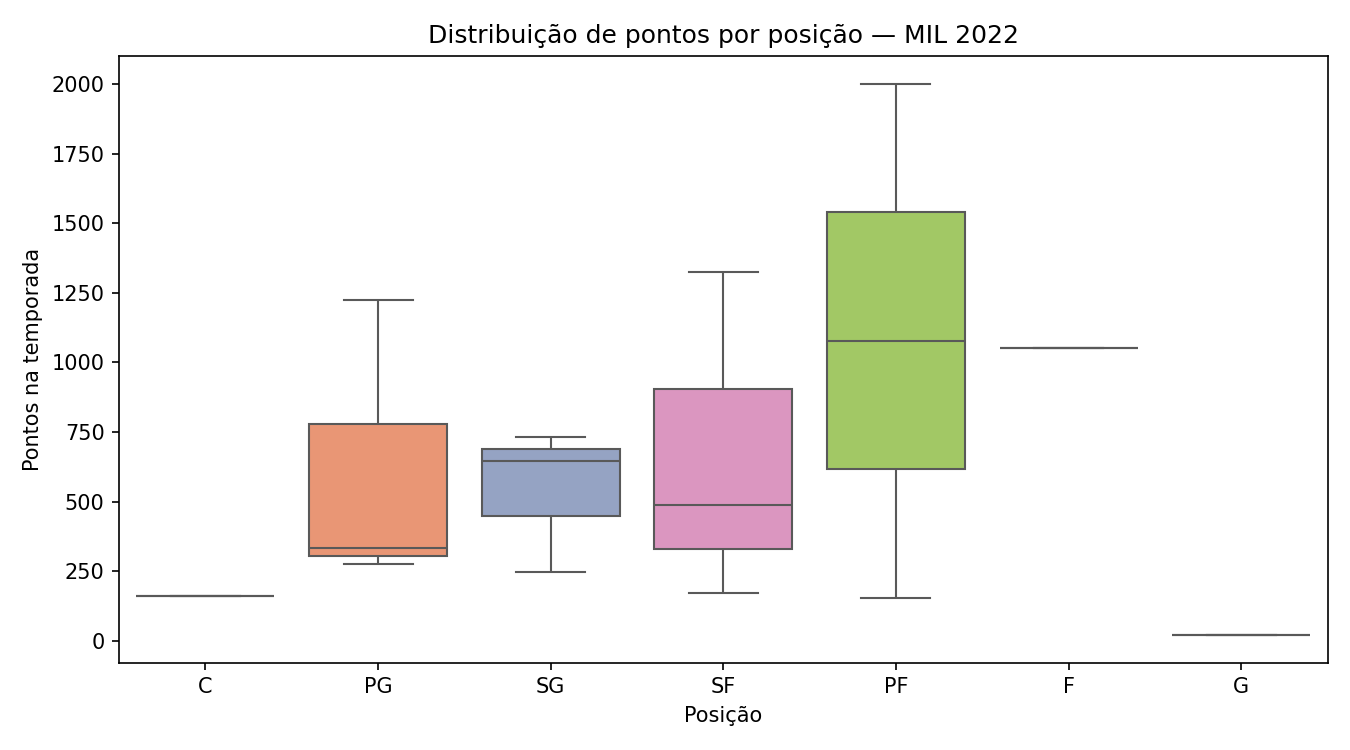

In [ ]:
# Boxplot pontos por posição MIL 2022

### 2.6 Jogadores abaixo da média da sua posição — 2022

In [ ]:
cols2 = ['pontos', 'rebotes', 'assistencias']

# Média do time
media_time = df_2022[cols2].mean()
df_2022['abaixo_media'] = df_2022['pontos'] < media_time['pontos']
fracos = df_2022[df_2022['abaixo_media']][['nome_jogador','sigla_posicao','pontos','rebotes','assistencias']]
print("Jogadores abaixo da média geral:")
print(fracos.to_string(index=False))

# Média por posição
media_posicao = df_2022.groupby('sigla_posicao')[cols2].mean()
df_comp = df_2022.merge(media_posicao, on='sigla_posicao', suffixes=('','_media'))
df_comp['abaixo_media_posicao'] = df_comp['pontos'] < df_comp['pontos_media']
print("\nJogadores abaixo da média da própria posição:")
print(df_comp[['nome_jogador','sigla_posicao','pontos','pontos_media','abaixo_media_posicao']].to_string(index=False))

In [ ]:
df_comp_sorted = df_comp.sort_values('pontos', ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
cores = ['steelblue' if not a else 'tomato' for a in df_comp_sorted['abaixo_media_posicao']]
ax.bar(df_comp_sorted['nome_jogador'], df_comp_sorted['pontos'], color=cores)
cores_pos = ['black','purple','darkorange','green','brown']
for i, (pos, grupo) in enumerate(df_comp_sorted.groupby('sigla_posicao')):
    media_p = grupo['pontos_media'].iloc[0]
    nomes = list(df_comp_sorted['nome_jogador'])
    xi = nomes.index(grupo['nome_jogador'].iloc[0])
    xf = nomes.index(grupo['nome_jogador'].iloc[-1])
    ax.hlines(media_p, xi-0.4, xf+0.4, colors=cores_pos[i%len(cores_pos)],
              linestyles='--', linewidth=2, label=f'Média {pos}')
plt.xticks(rotation=45, ha='right')
plt.title('Pontos por jogador vs média da posição — MIL 2022\n(vermelho = abaixo da média da posição)')
plt.legend()
plt.tight_layout()
plt.show()

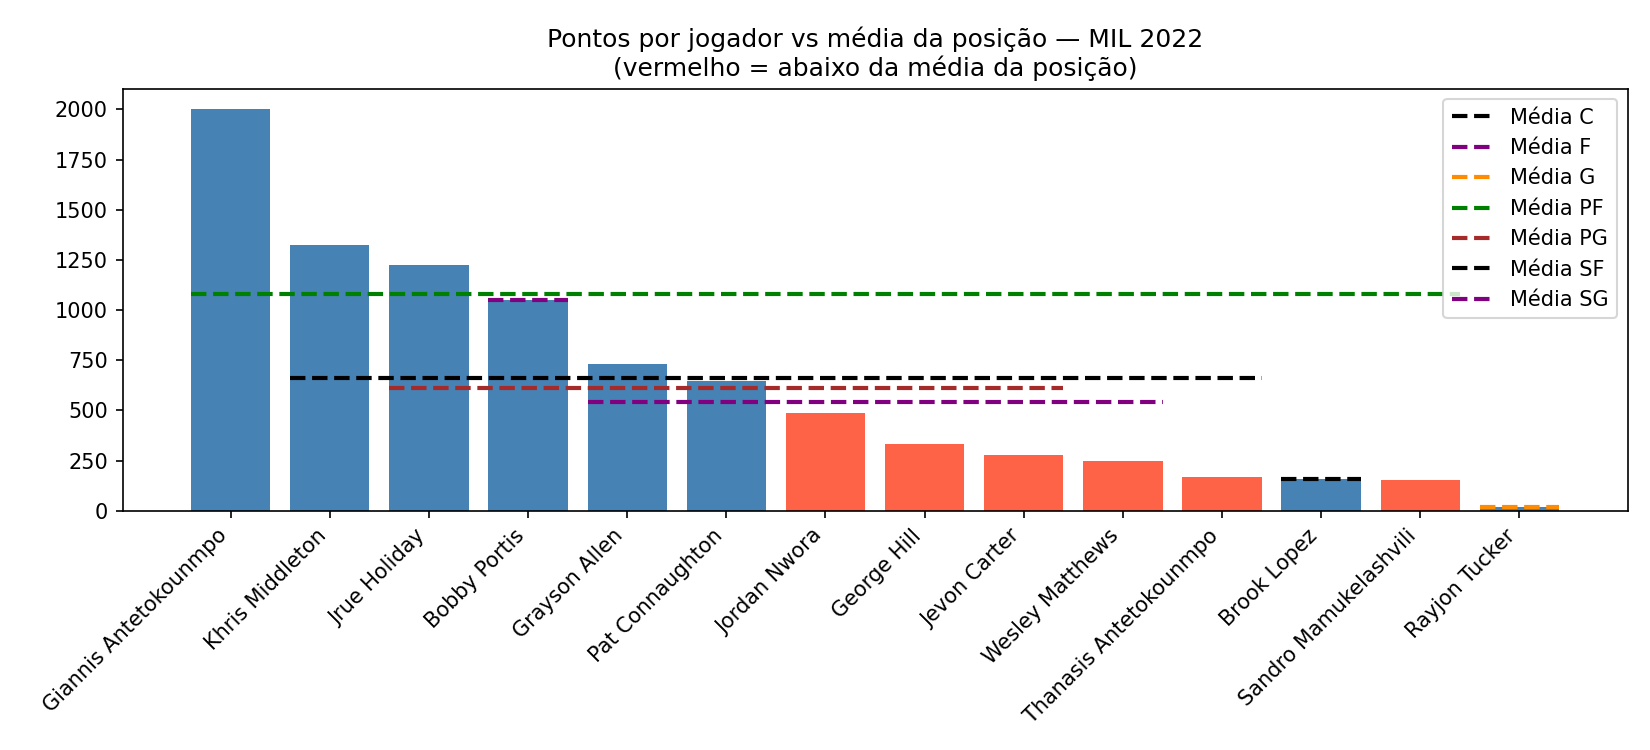

In [ ]:
# Jogadores abaixo da média por posição — 2022

### 2.7 Salário dos jogadores de Ala (SF e PF) — 2022

In [ ]:
ala_positions = ['SF', 'PF']
df_alas = df_2022[df_2022['sigla_posicao'].isin(ala_positions)].copy()
media_sal   = df_alas['salario_usd'].mean()
mediana_sal = df_alas['salario_usd'].median()

plt.figure(figsize=(10, 6))
sns.barplot(x='nome_jogador', y='salario_usd',
            data=df_alas.sort_values('salario_usd', ascending=False),
            hue='nome_jogador', palette='viridis', legend=False)
plt.axhline(media_sal,   color='red',   linestyle='--', label=f'Média: \${media_sal:,.0f}')
plt.axhline(mediana_sal, color='green', linestyle=':',  label=f'Mediana: \${mediana_sal:,.0f}')
plt.title('Salário dos Jogadores de Ala (SF e PF) — MIL 2022')
plt.xlabel('Nome do Jogador')
plt.ylabel('Salário (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

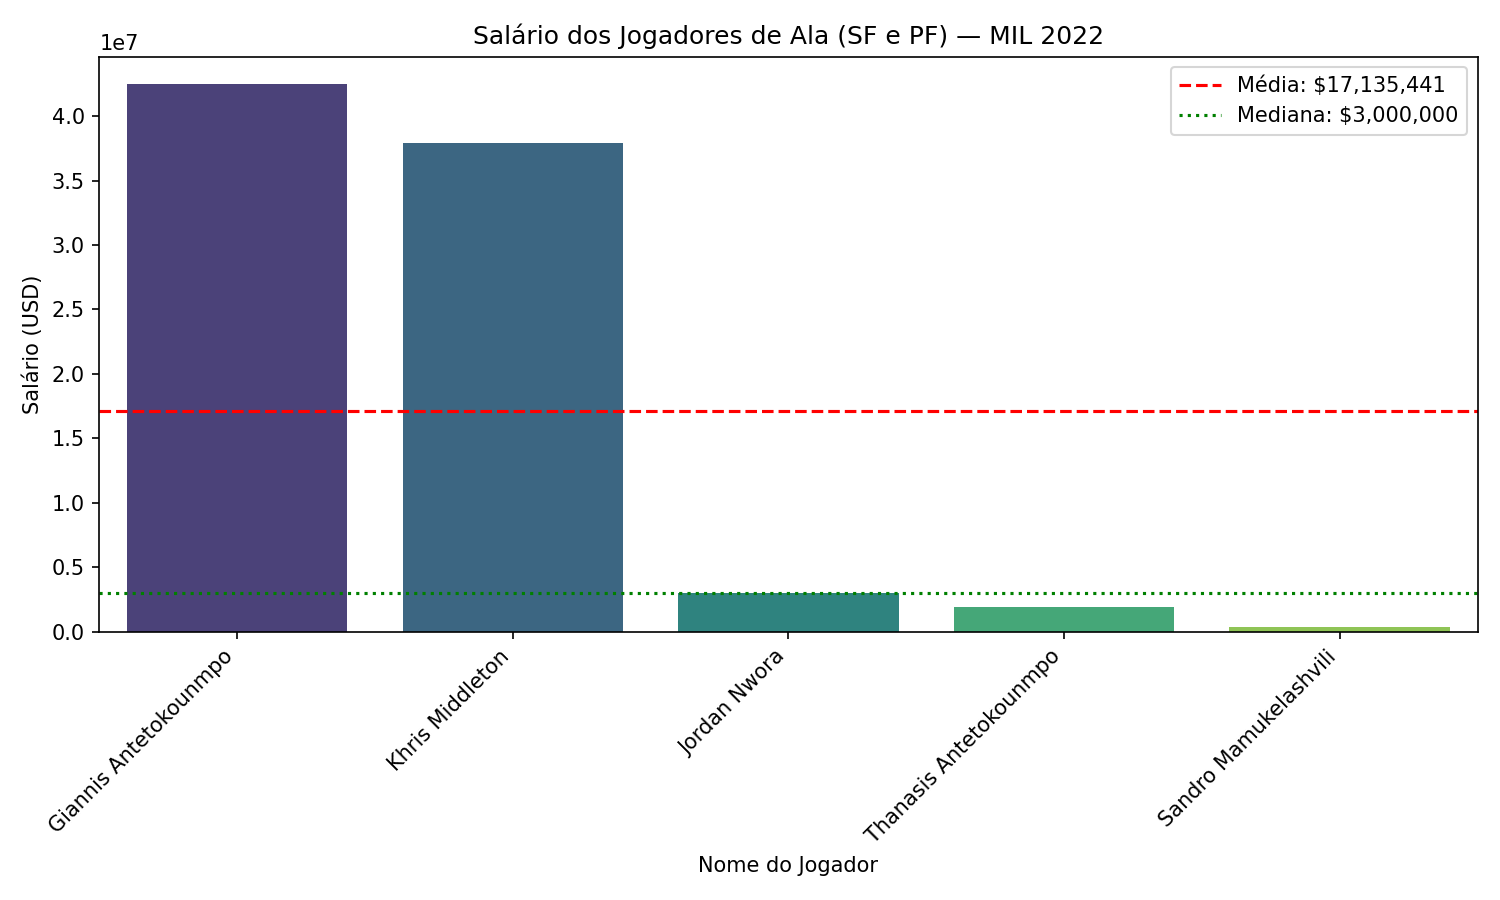

In [ ]:
# Salário alas MIL 2022

### 2.8 Dispersão: Pontos vs Salário — 2022

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(df_2022['pontos'], df_2022['salario_usd'],
            alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.5, s=60)
z = np.polyfit(df_2022['pontos'], df_2022['salario_usd'], 1)
p = np.poly1d(z)
xl = np.linspace(df_2022['pontos'].min(), df_2022['pontos'].max(), 100)
plt.plot(xl, p(xl), color='red', linestyle='--', linewidth=1.5, label='Tendência')
plt.title('Dispersão: Pontos vs Salário — MIL 2022')
plt.xlabel('Pontos na temporada')
plt.ylabel('Salário (USD)')
plt.legend()
plt.tight_layout()
plt.show()

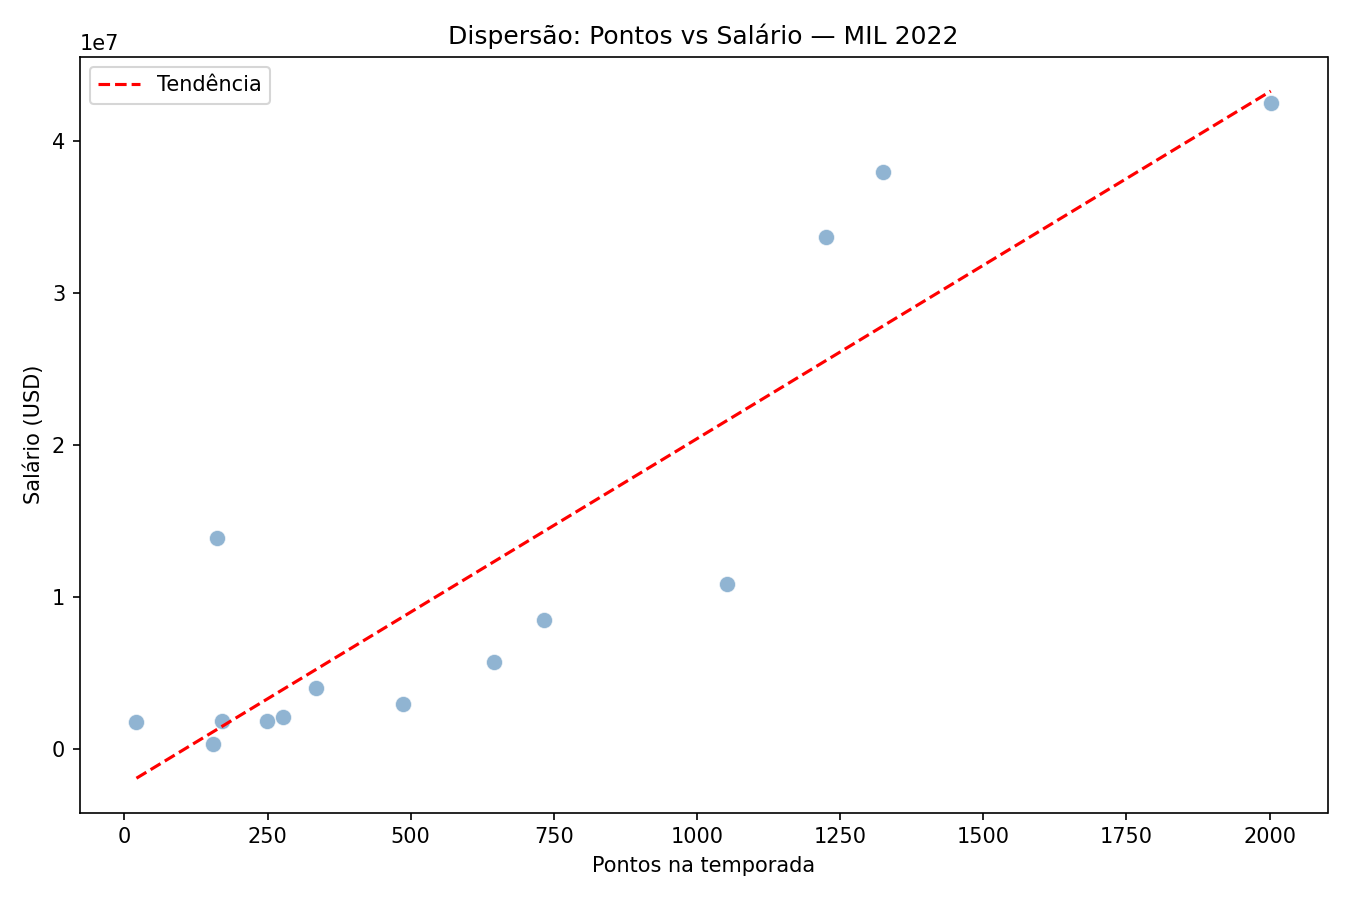

In [ ]:
# Dispersão pontos vs salário 2022

**Interpretação:** O gráfico de dispersão entre pontos e salário dos jogadores do Milwaukee Bucks revela uma tendência positiva — à medida que a pontuação aumenta, o salário também tende a crescer. Isso sugere que o desempenho ofensivo é um fator relevante na remuneração dos atletas do time. No entanto, a dispersão dos pontos ao redor da linha de tendência indica que pontuação não é o único critério salarial, havendo jogadores com salários acima ou abaixo do esperado para sua pontuação.


---
## 3. Comparação entre as temporadas 2022 e 2023

Análise comparativa entre as duas temporadas para identificar padrões de variação no desempenho e salário dos jogadores do MIL.


### 3.1 Estatísticas descritivas comparativas

In [ ]:
cols = ['pontos', 'rebotes', 'assistencias', 'salario_usd']

def resumo_t(df_t, ano):
    return pd.DataFrame({
        f'Média {ano}':    df_t[cols].mean(),
        f'Mediana {ano}':  df_t[cols].median(),
        f'Q1 {ano}':       df_t[cols].quantile(0.25),
        f'Q3 {ano}':       df_t[cols].quantile(0.75),
    })

resumo_comp = pd.concat([resumo_t(df_2022, 2022), resumo_t(df_2023, 2023)], axis=1)
display(resumo_comp.round(2))

**Interpretação:** Em 2023 o MIL apresentou médias superiores em todas as métricas. A média de pontos subiu de **631 para 953** e a mediana de salário quase dobrou — de **$4,8M para $10,5M** — indicando um elenco mais experiente e valorizado.


### 3.2 Média vs Mediana — 2022 vs 2023

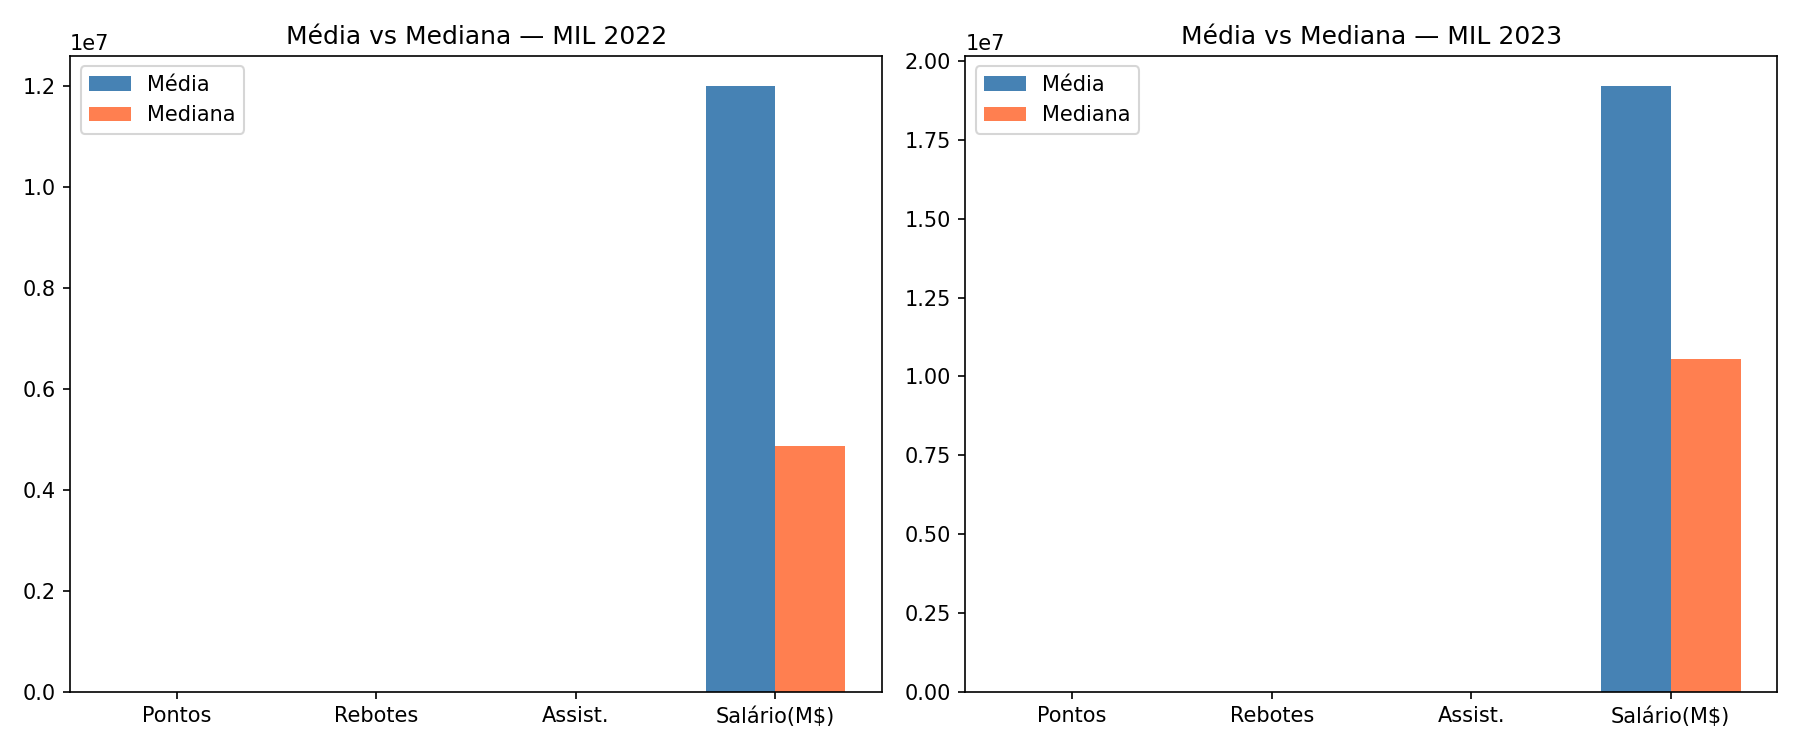

In [ ]:
# Média vs Mediana 2022 vs 2023

**Interpretação:** A diferença entre média e mediana é mais pronunciada no salário do que nas métricas de desempenho, especialmente em 2023. Isso confirma a **distribuição assimétrica à direita** — poucos jogadores com salários muito altos elevam a média acima da mediana.


### 3.3 Boxplot de pontos por posição — 2022 vs 2023

In [ ]:
df_comp2 = pd.concat([df_2022.assign(Temporada='2022'), df_2023.assign(Temporada='2023')])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_comp2, x='sigla_posicao', y='pontos', hue='Temporada',
            palette=['steelblue', 'coral'], ax=ax)
ax.set_title('Distribuição de pontos por posição — MIL 2022 vs 2023')
ax.set_xlabel('Posição')
ax.set_ylabel('Pontos')
plt.tight_layout()
plt.show()

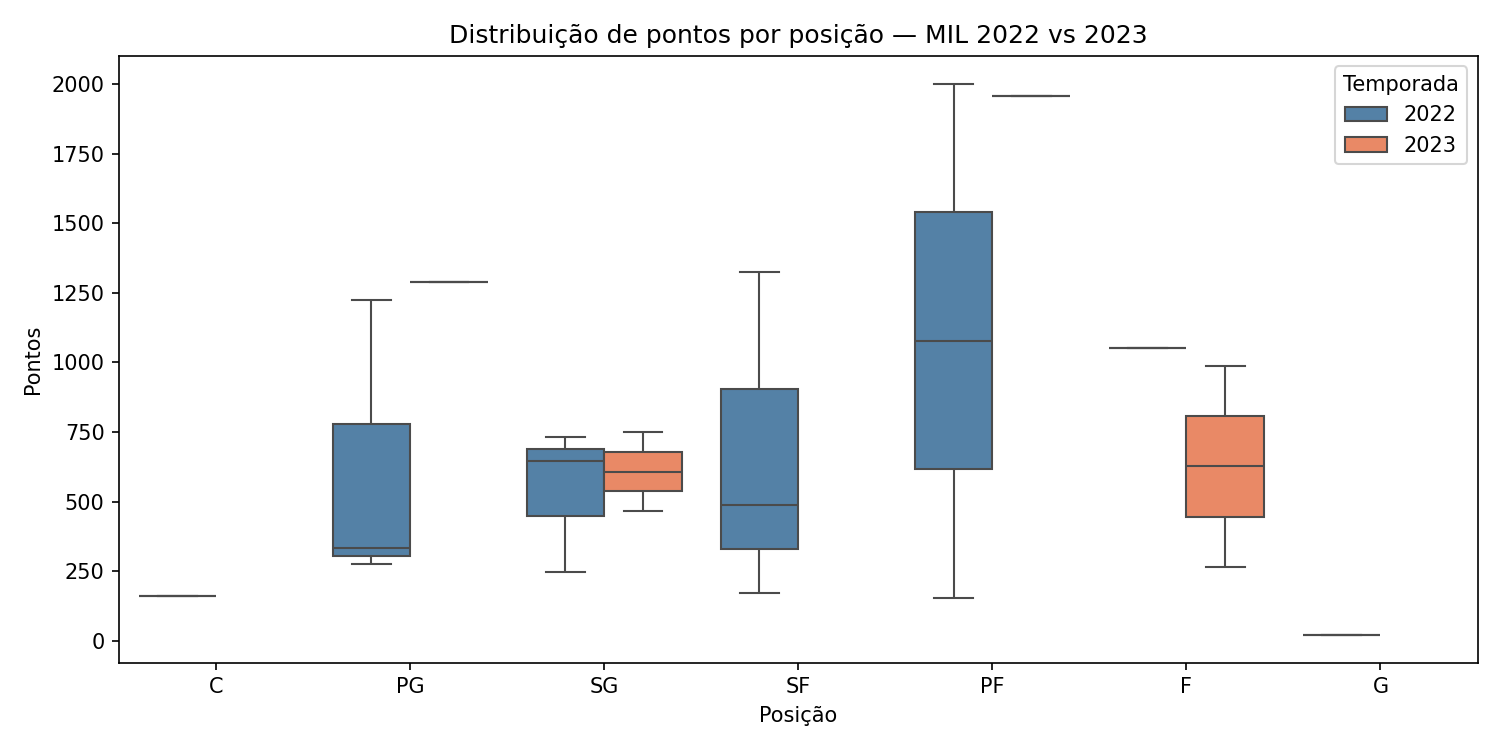

In [ ]:
# Boxplot pontos por posição 2022 vs 2023

### 3.4 Boxplot de salário por posição — 2022 vs 2023

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_comp2, x='sigla_posicao', y='salario_usd', hue='Temporada',
            palette=['steelblue', 'coral'], ax=ax)
ax.set_title('Distribuição de salário por posição — MIL 2022 vs 2023')
ax.set_xlabel('Posição')
ax.set_ylabel('Salário (USD)')
plt.tight_layout()
plt.show()

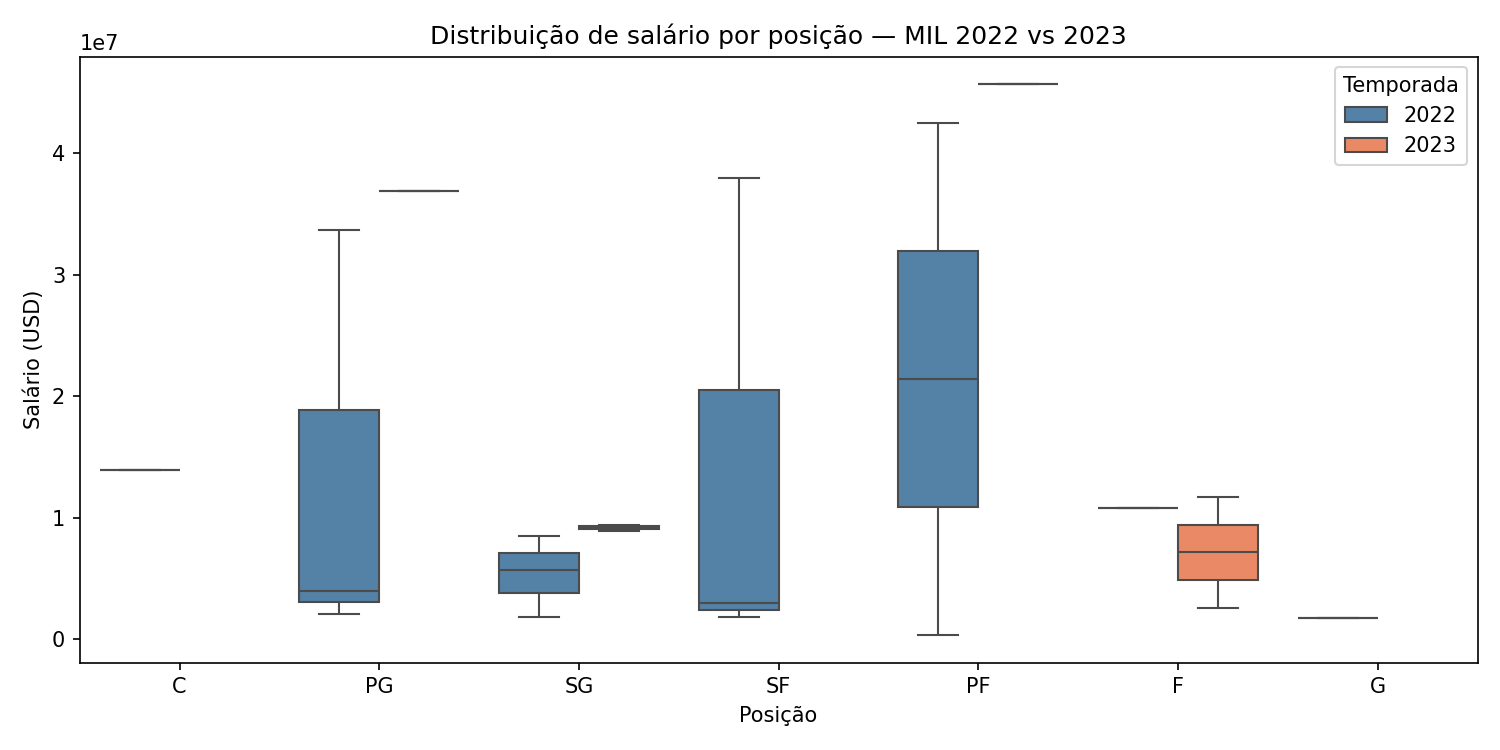

In [ ]:
# Boxplot salário por posição 2022 vs 2023

**Interpretação:** Em 2023, a amplitude salarial (IQR) aumentou para a maioria das posições, indicando maior desigualdade interna. Os contratos de longa duração e o valor de mercado dos jogadores contribuem para essa dispersão crescente.


### 3.5 Dispersão: Pontos vs Salário — 2022 vs 2023

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (df_t, ano, cor) in zip(axes, [(df_2022,2022,'steelblue'),(df_2023,2023,'coral')]):
    ax.scatter(df_t['pontos'], df_t['salario_usd'], alpha=0.7, color=cor,
               edgecolors='white', linewidths=0.5, s=80)
    z = np.polyfit(df_t['pontos'], df_t['salario_usd'], 1)
    p = np.poly1d(z)
    xl = np.linspace(df_t['pontos'].min(), df_t['pontos'].max(), 100)
    ax.plot(xl, p(xl), color='red', linestyle='--', linewidth=1.5, label='Tendência')
    for _, row in df_t.nlargest(3, 'pontos').iterrows():
        ax.annotate(row['nome_jogador'].split()[-1], (row['pontos'], row['salario_usd']),
                    textcoords='offset points', xytext=(5,5), fontsize=8)
    ax.set_title(f'Pontos vs Salário — MIL {ano}')
    ax.set_xlabel('Pontos')
    ax.set_ylabel('Salário (USD)')
    ax.legend()
plt.tight_layout()
plt.show()

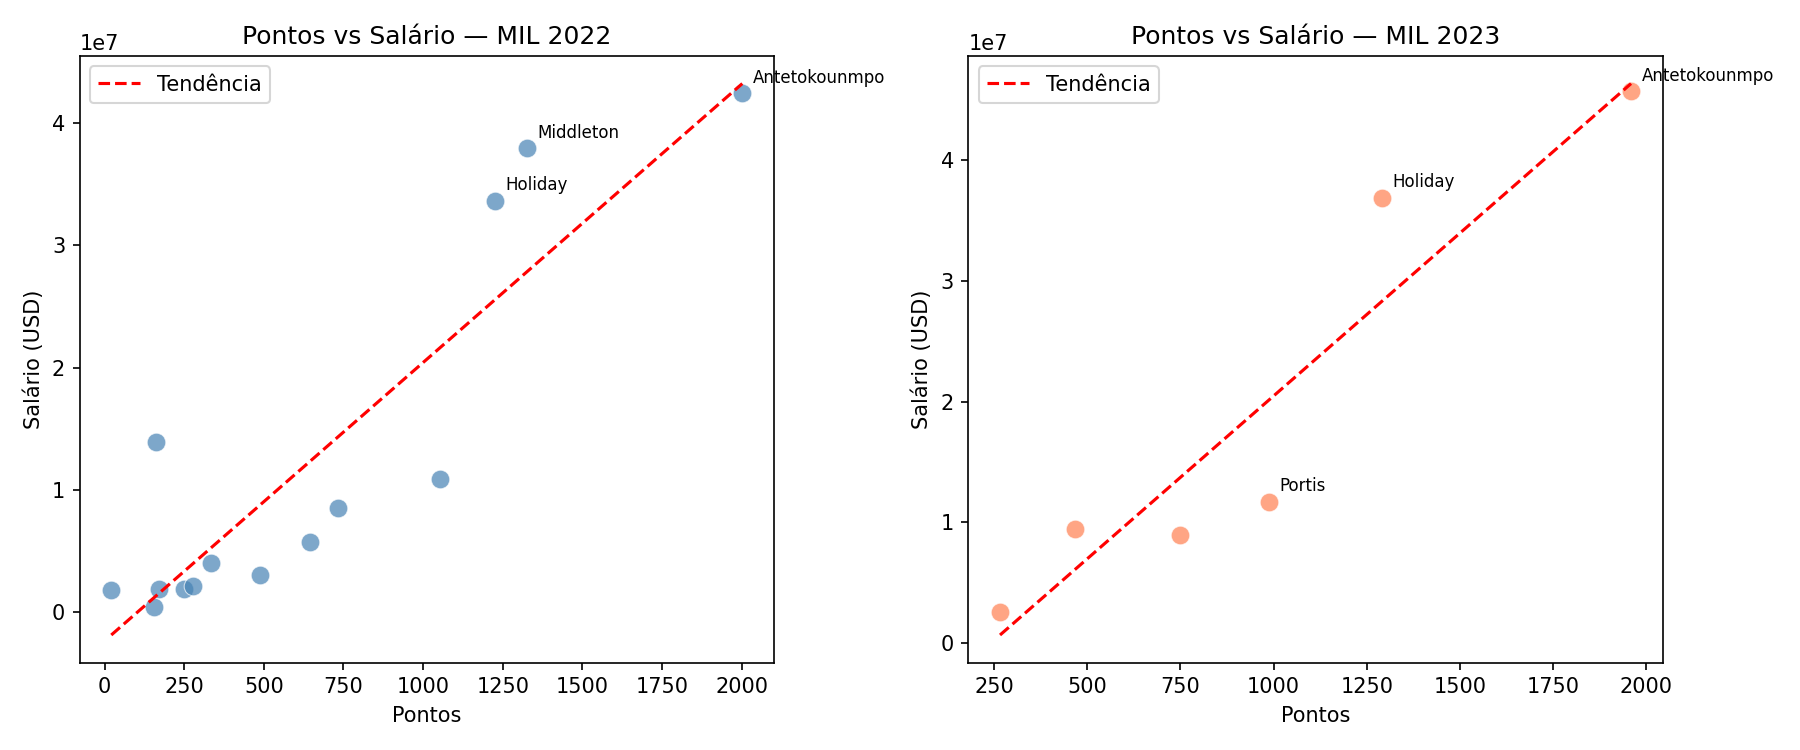

In [ ]:
# Dispersão 2022 vs 2023

**Interpretação:** A correlação positiva entre pontuação e salário se confirma nas duas temporadas. A tendência é mais clara em 2023, onde os pontos estão mais concentrados no elenco reduzido.


### 3.6 Variação individual — jogadores presentes nas duas temporadas

In [ ]:
jogadores_comuns = set(df_2022['nome_jogador']) & set(df_2023['nome_jogador'])
print(f'Jogadores em comum: {jogadores_comuns}')

d22 = df_2022[df_2022['nome_jogador'].isin(jogadores_comuns)][['nome_jogador','pontos','salario_usd']].set_index('nome_jogador')
d23 = df_2023[df_2023['nome_jogador'].isin(jogadores_comuns)][['nome_jogador','pontos','salario_usd']].set_index('nome_jogador')
delta = (d23 - d22).dropna()
delta.columns = ['Δ Pontos', 'Δ Salário (USD)']
display(delta.round(2))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(delta))
ax.bar([i-0.2 for i in x], delta['Δ Pontos'], 0.35,
       color=['steelblue' if v >= 0 else 'tomato' for v in delta['Δ Pontos']], label='Δ Pontos')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels([n.split()[-1] for n in delta.index], rotation=30, ha='right')
ax.set_title('Variação de pontos por jogador — MIL 2022 → 2023')
ax.set_ylabel('Δ Pontos')
ax.legend()
plt.tight_layout()
plt.show()

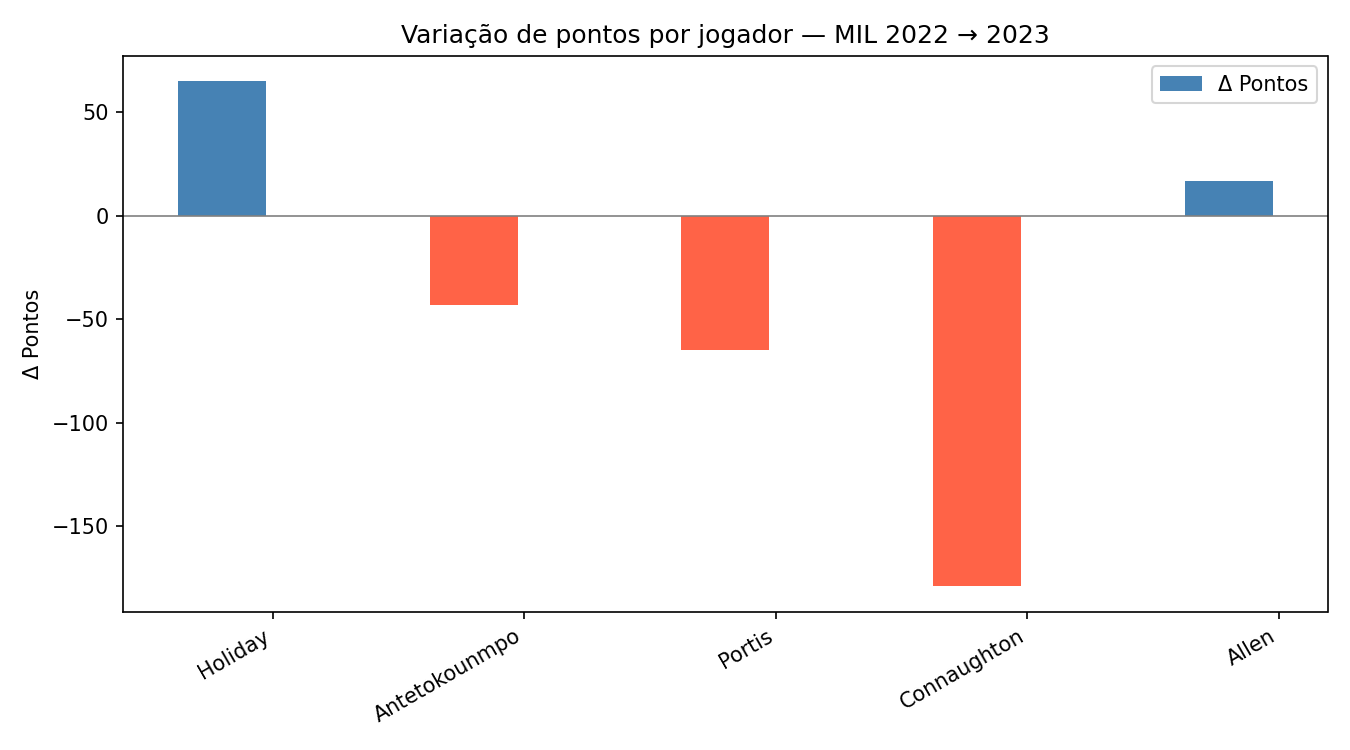

In [ ]:
# Variação individual 2022 vs 2023

**Interpretação:** Entre os 5 jogadores presentes nas duas temporadas, a maioria teve redução de pontos mas aumento de salário. O caso mais notável é o **Giannis**, que pontuou 43 pontos a menos em 2023 mas recebeu $3,1M a mais — mostrando que contratos de longa duração e valor de mercado têm peso independente do desempenho de uma única temporada.


---
## 4. Conclusão

A análise comparativa das temporadas **2022 e 2023** do Milwaukee Bucks revela os seguintes padrões:

- **Desempenho coletivo superior em 2023:** médias de pontos, rebotes e assistências foram maiores.
- **Salários mais altos em 2023:** a mediana salarial quase dobrou, indicando um elenco mais valorizado.
- **Distribuição assimétrica:** em ambas as temporadas, a média salarial supera a mediana, evidenciando a influência de contratos milionários sobre a média do grupo.
- **Correlação positiva entre pontos e salário:** confirmada pelo gráfico de dispersão nas duas temporadas.
- **Salário não depende só do desempenho:** jogadores que pontuaram menos em 2023 ainda receberam aumentos, indicando que valor de mercado e contratos de longo prazo têm peso independente do desempenho anual.
